# Gas Source Estimation with Unknown Wind

This example jointly estimates three neural fields from sparse gas and wind
measurements:

$$
C_\phi:(x,y)\mapsto c_\phi(x,y)\geq0,
$$

$$
Q_\psi:(x,y)\mapsto q_\psi(x,y)\geq0,
$$

$$
W_\theta:(x,y)\mapsto
\bigl(u_\theta(x,y),v_\theta(x,y),p_\theta(x,y)\bigr).
$$

$C_\phi$ is the concentration network, $Q_\psi$ the source network, and
$W_\theta$ the wind-and-pressure network. Their outputs are denoted by
$c_\phi$, $q_\psi$, and $(u_\theta,v_\theta,p_\theta)$, respectively. The
complete wind field is unknown; only sparse measurements
$\hat{\mathbf u}_i$ are available alongside sparse gas measurements $\hat c_i$.

The wind network is constrained by the stationary incompressible
Navier–Stokes equations

$$
\nabla\cdot\mathbf u_\theta=0,
$$

$$
(\mathbf u_\theta\cdot\nabla)\mathbf u_\theta
+\nabla p_\theta
-\nu\Delta\mathbf u_\theta
=\mathbf 0.
$$

The concentration, source, and wind networks are coupled through the stationary
advection–diffusion equation

$$
-D\Delta c_\phi
+\mathbf u_\theta\cdot\nabla c_\phi
-q_\psi
=0.
$$

Thus, the wind network is constrained by both the wind-related terms and its role
in gas transport. Conversely, the concentration and source estimates must be
compatible with the currently estimated wind field. All network parameters are
optimized jointly rather than estimating wind and gas in two separate stages.


In [ ]:
%cd /app

import matplotlib.pyplot as plt
import numpy as np
import torch

from source_estimation_pinn.environment import OccupancyGrid
from source_estimation_pinn.estimation import (
    WindGasSourceConfig,
    WindGasSourceEstimator,
)
from source_estimation_pinn.measurements import GasSampleSet, WindSampleSet

# Synthetic example data
case_dir = "data/example_labyrinth"
true_source = np.array([9.0, 4.5])  # evaluation only, not used for training

torch.manual_seed(12)
occupancy = OccupancyGrid.from_msh_file(
    f"{case_dir}/labyrinth_2d_fine.msh", resolution=0.1
)
gas_samples = GasSampleSet.from_csv(
    f"{case_dir}/gas_gt9.0_4.5.csv", n=50, random_seed=1
)
wind_samples = WindSampleSet.from_csv(
    f"{case_dir}/wind_gt.csv", n=50, random_seed=2
)


/app



## Information and constraints used during training

The estimate is based on four sources of information:

1. **Gas measurements:** $c_\phi(x_i,y_i)$ is fitted to the measured
   concentrations $\hat c_i$.
2. **Wind measurements:** $\mathbf u_\theta(x_i,y_i)$ is fitted to the measured
   velocity vectors $\hat{\mathbf u}_i$.
3. **Physical equations:** Navier–Stokes constrains wind and pressure, while the
   advection–diffusion equation couples wind, concentration, and source.
4. **Domain geometry:** the occupancy grid provides free space, solid walls, and
   open boundaries from which the boundary losses are constructed.

The geometry imposes the following conditions and priors:

- no-slip wind, $\mathbf u_\theta=\mathbf 0$, at solid walls;
- zero normal gas flux, $\nabla c_\phi\cdot\mathbf n=0$, at solid walls;
- zero gas concentration at open-boundary points currently classified as inflow
  by $\mathbf u_\theta\cdot\mathbf n<0$;
- suppression of the source field outside free space;
- a sparsity prior favoring a spatially compact positive source;
- a fixed free-space pressure reference, $p_\theta(x_\mathrm{ref},y_\mathrm{ref})=0$, that removes the arbitrary pressure offset.

The resulting shared objective can be summarized as

$$
\mathcal L =
\mathcal L_\mathrm{gas\ data}
+\mathcal L_\mathrm{wind\ data}
+\mathcal L_\mathrm{AD}
+\mathcal L_\mathrm{NS}
+\mathcal L_\mathrm{boundary}
+\mathcal L_\mathrm{source\ prior}.
$$

A single Adam optimizer updates all three networks from this total loss. Separate
learning rates are used only as optimizer parameter-group settings; they do not
turn the procedure into separate training stages.


In [52]:
config = WindGasSourceConfig(
    concentration_hidden_layers=3,
    concentration_hidden_dim=32,
    source_hidden_layers=2,
    source_hidden_dim=32,
    wind_hidden_layers=3,
    wind_hidden_dim=32,
    diffusion_constant=1e-3,
    lambda_sparse=1e-3,
    lambda_nonfree=1e-1,
    lambda_pressure=0.0,
    lambda_div=1.0,
    lambda_momentum=1.0,
    lambda_wind_smooth=0.01,
    lambda_wind_data=1.0,
    lambda_wind_wall=1.0,
    learning_rate=2e-3,
    wind_learning_rate=1e-3,
)

estimator = WindGasSourceEstimator(occupancy=occupancy, config=config)
history = estimator.fit(
    gas_samples,
    wind_samples,
    steps=1000,
    n_collocation_points=len(occupancy.free_points) // 2,
)


Estimated source: [9.95 1.65]
Distance to truth: 3.0041637771599605


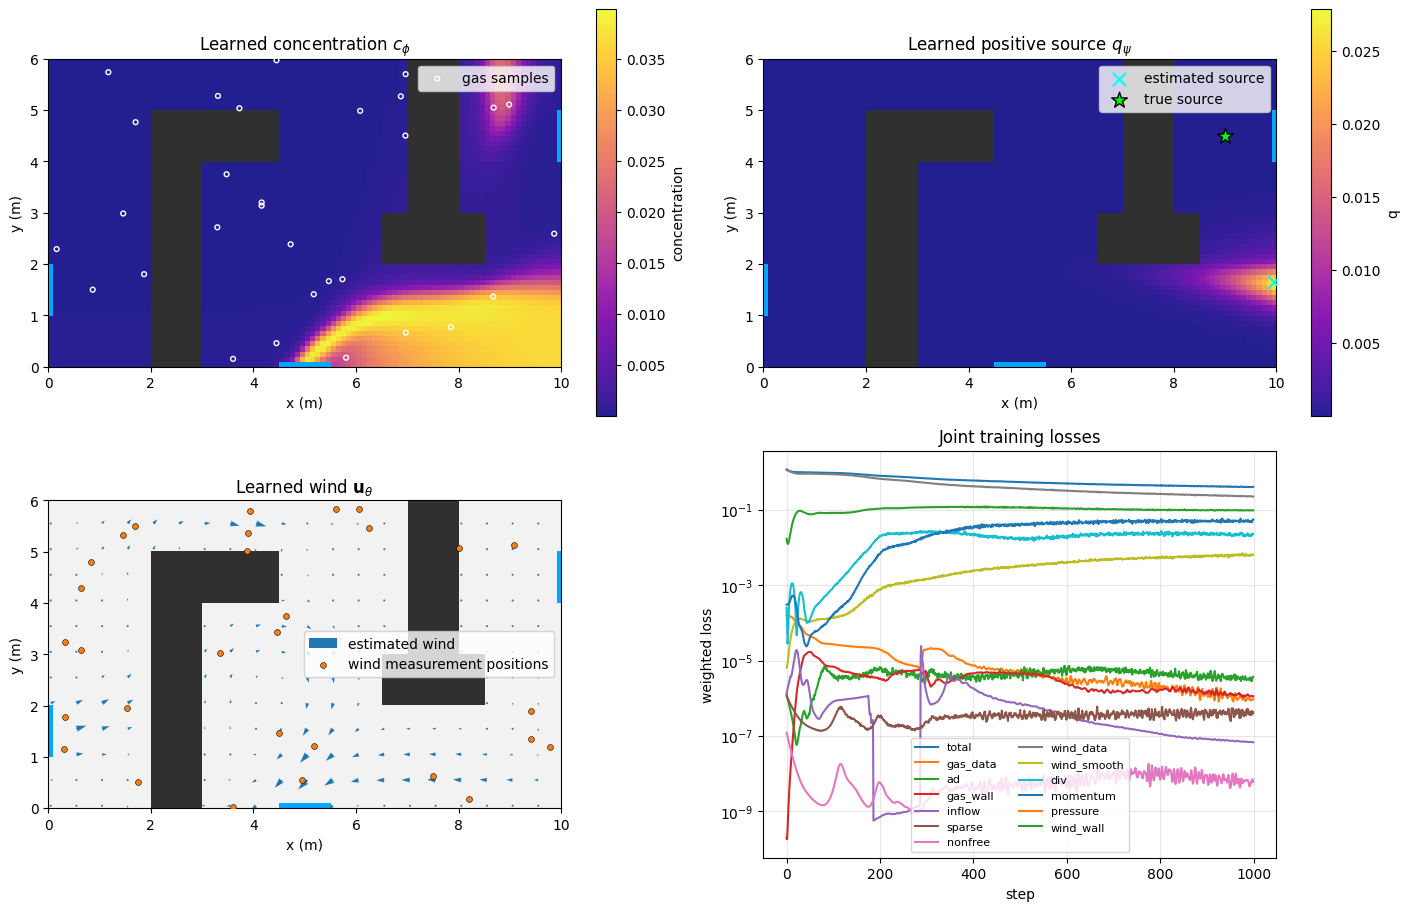

In [53]:
# Evaluate concentration, source, and wind on the free grid cells.
free_points = occupancy.free_points
c_free = estimator.predict_concentration(free_points)
q_free = estimator.predict_source(free_points)
uv_free = estimator.predict_wind(free_points)
source_estimate = estimator.get_source_estimate()

fields = []
for prediction in (c_free, q_free):
    field = np.full(occupancy.occupancy.shape, np.nan)
    field[occupancy.free_mask] = prediction
    fields.append(field)

extent = [
    occupancy.lower_bound[0], occupancy.upper_bound[0],
    occupancy.lower_bound[1], occupancy.upper_bound[1],
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

for ax, field, title, label in zip(
    axes[0],
    fields,
    (r"Learned concentration $c_\phi$", r"Learned positive source $q_\psi$"),
    ("concentration", "q"),
):
    occupancy.plot(ax=ax, title=title)
    ax.get_legend().remove()
    image = ax.imshow(
        field, origin="lower", extent=extent, cmap="plasma",
        interpolation="nearest", alpha=0.9, zorder=2,
    )
    fig.colorbar(image, ax=ax, label=label)

axes[0, 0].scatter(
    *gas_samples.positions.T, s=12, facecolors="none", edgecolors="white",
    label="gas samples", zorder=4,
)
axes[0, 0].legend()
axes[0, 1].scatter(
    *source_estimate, marker="x", s=90, color="cyan",
    label="estimated source", zorder=5,
)
axes[0, 1].scatter(
    *true_source, marker="*", s=140, color="lime", edgecolor="black",
    label="true source", zorder=5,
)
axes[0, 1].legend()

# Use a regular 2D subgrid; slicing flattened points would create stripes.
rows, columns = np.indices(occupancy.free_mask.shape)
plot_mask = (
    occupancy.free_mask
    & (rows % 5 == 0)
    & (columns % 5 == 0)
)
xx, yy = np.meshgrid(occupancy.x_centers, occupancy.y_centers)
wind_plot_points = np.column_stack((xx[plot_mask], yy[plot_mask]))
uv_plot = estimator.predict_wind(wind_plot_points)

ax = axes[1, 0]
occupancy.plot(ax=ax, title=r"Learned wind $\mathbf{u}_\theta$")
ax.get_legend().remove()
quiver_options = dict(angles="xy", scale_units="xy", scale=8.0, zorder=3)
ax.quiver(
    wind_plot_points[:, 0], wind_plot_points[:, 1],
    uv_plot[:, 0], uv_plot[:, 1],
    color="tab:blue", label="estimated wind", **quiver_options,
)
ax.scatter(
    wind_samples.positions[:, 0], wind_samples.positions[:, 1],
    s=18, color="tab:orange", edgecolor="black", linewidth=0.4,
    label="wind measurement positions", zorder=4,
)
ax.legend()

ax = axes[1, 1]
for name, values in history.losses.items():
    values = np.asarray(values)
    ax.semilogy(np.where(values > 0, values, np.nan), label=name)
ax.set(title="Joint training losses", xlabel="step", ylabel="weighted loss")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, ncol=2)

print("Estimated source:", source_estimate)
print("Distance to truth:", np.linalg.norm(source_estimate - true_source))
plt.show()
